In [2]:
import numpy as np
import pandas as pd
import polars as pl
import seaborn as sns

import matplotlib.pyplot as plt
from sklearn.tree import plot_tree
from sklearn.model_selection import train_test_split
from sksurv.ensemble import RandomSurvivalForest
from sksurv.linear_model import CoxPHSurvivalAnalysis
from sksurv.metrics import concordance_index_censored , concordance_index_ipcw
from sklearn.impute import SimpleImputer
from sksurv.util import Surv

from sklearn.experimental import enable_iterative_imputer
from sklearn.impute import IterativeImputer
from sklearn.ensemble import RandomForestRegressor




In [3]:
# Raw data


# Clinical Data
df = pl.read_csv("../data/raw/X_train/clinical_train.csv")
df_eval = pl.read_csv("../data/raw/X_test/clinical_test.csv")



# TRAITEMENT DE CLINICAL DATA SET


In [4]:
# Clinical Data
df.null_count()

ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS
u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,109,272,193,601,110,124,387


In [5]:
df.describe()

statistic,ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS
str,str,str,f64,f64,f64,f64,f64,f64,str
"""count""","""3323""","""3323""",3214.0,3051.0,3130.0,2722.0,3213.0,3199.0,"""2936"""
"""null_count""","""0""","""0""",109.0,272.0,193.0,601.0,110.0,124.0,"""387"""
"""mean""",null,null,5.982545,6.535164,3.264735,0.955868,9.893549,167.0489,null
"""std""",null,null,7.615439,10.247219,5.237043,2.666478,2.041158,149.477031,null
"""min""","""P100000""","""CCH""",0.0,0.2,0.0,0.0,4.0,2.0,"""+8(fish)"""
"""25%""",null,null,1.0,2.7,1.0,0.15,8.5,66.0,null
"""50%""",null,null,3.0,4.1,2.0,0.37,9.7,123.0,null
"""75%""",null,null,8.0,6.66,3.69,0.784,11.2,230.0,null
"""max""","""P132729""","""VU""",91.0,154.4,109.62,44.2,16.6,1451.0,"""tris8"""


In [284]:
quant_vars = ["BM_BLAST", "WBC", "ANC", "MONOCYTES", "HB", "PLT"]
sub_df = df.select(quant_vars)

# Convert to pandas
sub_pd = sub_df.to_pandas()

# Apply Model-Based Imputation (Random Forest)
imputer = IterativeImputer(estimator=RandomForestRegressor(), random_state=42)
imputed_data = imputer.fit_transform(sub_pd)

# 4. To Polars
imputed_pl = pl.DataFrame(imputed_data, schema=sub_df.columns)

# 5. Replace nulls
df = df.with_columns([imputed_pl[col].alias(col) for col in quant_vars])

c:\Users\zakar\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\impute\_iterative.py:895: ConvergenceWarning: [IterativeImputer] Early stopping criterion not reached.
  warnings.warn(


In [285]:
df.null_count()

ID,CENTER,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS
u32,u32,u32,u32,u32,u32,u32,u32,u32
0,0,0,0,0,0,0,0,387


# OUTLIERS TREATEMENT

# Method IQR 

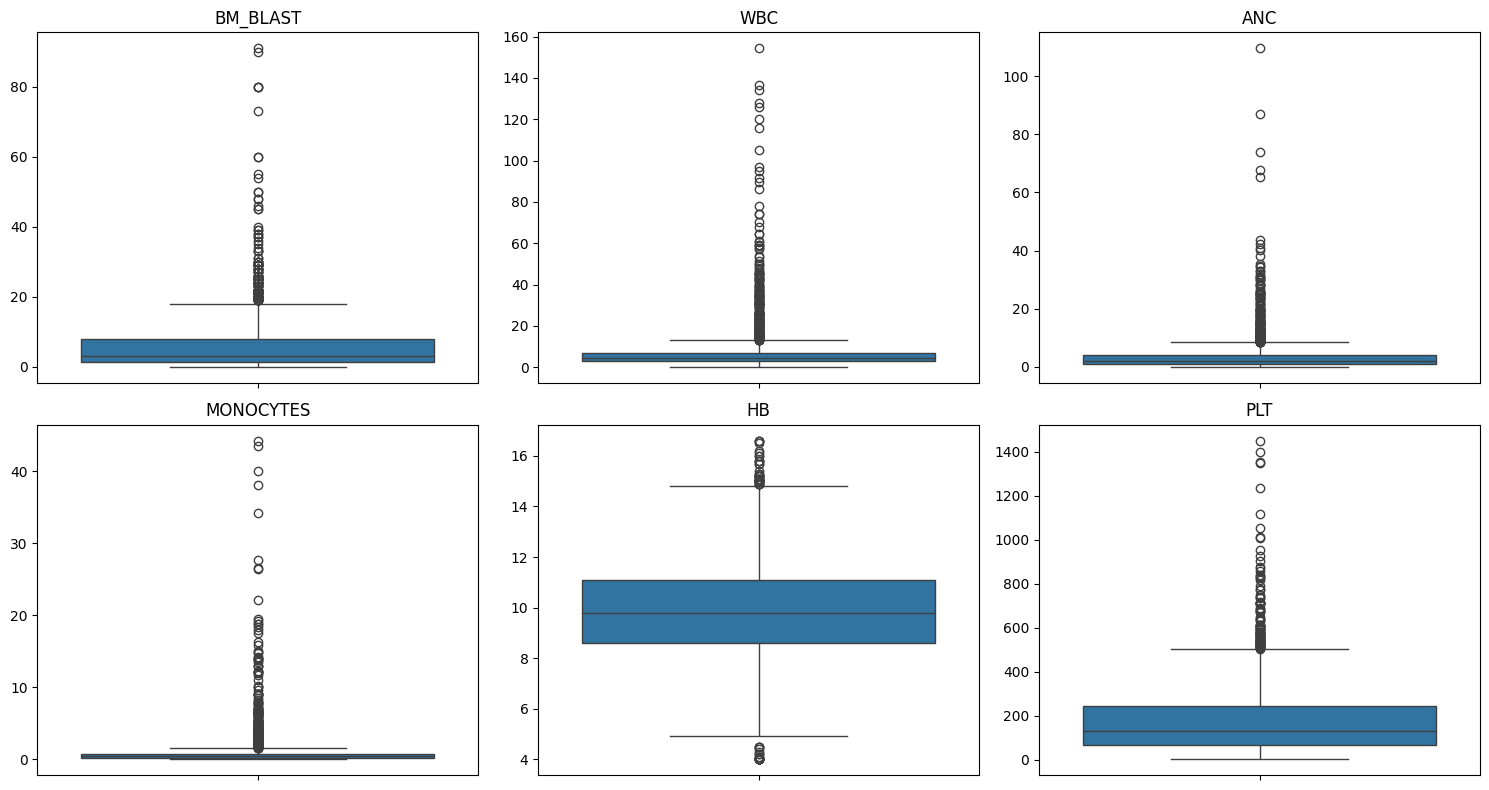

In [288]:
cl_quantitative_var = ["BM_BLAST", "WBC", "ANC", "MONOCYTES", "HB", "PLT"]



row = 2
col = 3

plt.figure(figsize=(15, 8)) 


for (index , cl )  in enumerate(cl_quantitative_var):
    
    plt.subplot(row,col,index + 1)
    plt.title(cl)
    sns.boxplot(df[cl])

plt.tight_layout()
plt.show()  

In [289]:
# Clinical Data

cl_quantitative_var = ["BM_BLAST", "WBC", "ANC", "MONOCYTES", "HB", "PLT"]



row = 2
col = 3


plt.figure(figsize=(15, 8)) 


for (index , cl )  in enumerate(cl_quantitative_var):
    q1 = df.select(pl.col(cl).quantile(0.25)).item()
    q3 = df.select(pl.col(cl).quantile(0.75)).item()
    
    iqr = q3 - q1
    
    
    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    outliers = df.filter(
        (pl.col(cl) < lower_bound) | (pl.col(cl) > upper_bound)
    )
    

    # Winsorisation : caper les valeurs extrêmes
    df = df.with_columns(
        pl.when(pl.col(cl) < lower_bound).then(lower_bound)
        .when(pl.col(cl) > upper_bound).then(upper_bound)
        .otherwise(pl.col(cl))
        .alias(cl)
    )
    
    
    
    print(f"Number of outliers in column : {cl} is : {outliers[cl].shape[0]}")


Number of outliers in column : BM_BLAST is : 181
Number of outliers in column : WBC is : 218
Number of outliers in column : ANC is : 192
Number of outliers in column : MONOCYTES is : 337
Number of outliers in column : HB is : 58
Number of outliers in column : PLT is : 104


<Figure size 1500x800 with 0 Axes>

In [290]:
df["CENTER"].value_counts()

CENTER,count
str,u32
"""ROM""",104
"""REL""",6
"""MUV""",83
"""RMCN""",199
"""UOXF""",50
…,…
"""GESMD""",246
"""MSK""",37
"""UOB""",88


In [291]:


cl_quantitative_var = ["BM_BLAST", "WBC", "ANC", "MONOCYTES", "HB", "PLT"]

for cl in cl_quantitative_var:
    mean = df.select(pl.col(cl).mean()).item()
    std = df.select(pl.col(cl).std()).item()

    z_scores = df.select(((pl.col(cl) - mean) / std).alias("z"))

    # On ajoute les Z-scores temporairement au DataFrame
    df_with_z = df.with_columns(((pl.col(cl) - mean) / std).alias(f"z_{cl}"))

    # Filtrer les outliers : abs(Z) > 3
    outliers = df_with_z.filter(pl.col(f"z_{cl}").abs() > 3)
    
    
    # Median
    median_val = df.select(pl.col(cl).median()).item()

    df = df.with_columns(
        pl.when((pl.col(cl) < lower_bound) | (pl.col(cl) > upper_bound))
        .then(median_val)
        .otherwise(pl.col(cl))
        .alias(cl)
    )
    
    
    # # Winsorisation : caper les valeurs extrêmes
    # df = df.with_columns(
    #     pl.when(pl.col(cl) < lower_bound).then(lower_bound)
    #     .when(pl.col(cl) > upper_bound).then(upper_bound)
    #     .otherwise(pl.col(cl))
    #     .alias(cl)
    # )

    print(f"Number of outliers in column : {cl} is : {outliers[cl].shape[0]}")

Number of outliers in column : BM_BLAST is : 0
Number of outliers in column : WBC is : 0
Number of outliers in column : ANC is : 0
Number of outliers in column : MONOCYTES is : 0
Number of outliers in column : HB is : 0
Number of outliers in column : PLT is : 0


# ENCODING

In [292]:
df["CENTER"].value_counts() # Catecorigal => Nominal , without any order

CENTER,count
str,u32
"""CCH""",159
"""ICO""",71
"""MUV""",83
"""HIAE""",47
"""PV""",316
…,…
"""KI""",900
"""VU""",33
"""MSK""",37


In [293]:
import category_encoders as ce

df_pd = df.to_pandas()

encoder = ce.BinaryEncoder(cols=["CENTER"])
df_encoded = encoder.fit_transform(df_pd)

df = pl.from_pandas(df_encoded)

df

# On encode avec le binary encoder car il n'intorduit pas d'ordre artificiel + n'explose pas le nombre de colonne + correct pour bcp de categories !

ID,CENTER_0,CENTER_1,CENTER_2,CENTER_3,CENTER_4,BM_BLAST,WBC,ANC,MONOCYTES,HB,PLT,CYTOGENETICS
str,i64,i64,i64,i64,i64,f64,f64,f64,f64,f64,f64,str
"""P132697""",0,0,0,0,1,14.0,2.8,0.2,0.7,7.6,119.0,"""46,xy,del(20)(q12)[2]/46,xy[18…"
"""P132698""",0,0,0,0,1,1.0,7.4,2.4,0.1,11.6,42.0,"""46,xx"""
"""P116889""",0,0,0,0,1,15.0,3.7,2.1,0.1,14.2,81.0,"""46,xy,t(3;3)(q25;q27)[8]/46,xy…"
"""P132699""",0,0,0,0,1,1.0,3.9,1.9,0.1,8.9,77.0,"""46,xy,del(3)(q26q27)[15]/46,xy…"
"""P132700""",0,0,0,0,1,6.0,13.129,8.45,0.9,11.1,195.0,"""46,xx,t(3;9)(p13;q22)[10]/46,x…"
…,…,…,…,…,…,…,…,…,…,…,…,…
"""P121828""",1,0,1,1,1,1.0,3.7,2.53,0.53,8.9,499.0,"""46,xy[20]"""
"""P121829""",1,0,1,1,1,0.0,4.2,2.4,0.22,10.6,49.0,"""46,xy,del(13)(q12q14)[1]/45,x,…"
"""P121830""",1,0,1,1,1,0.0,1.8,0.55,0.29,9.4,86.0,"""46,xy,del(20)(q11.2q13.1)[4]/4…"


# Ordinal encoding DNA Sequence

In [322]:
def dna_to_array(dna):
    lst = []
    
    nitrogen_bases = ['a','g','t','c']
    dna = dna.lower()
    
    
    for ch in dna:
        if(ch in nitrogen_bases):
            lst.append(ch)
        else:
            lst.append('n')
        
        
    return lst

def ordinal_encoder_dna(dna):
    mapping = {'a' : 0.25 , 'c' : 0.5 ,'g':0.75 , 't' : 1.00}
    
    nitrogen_bases = ['a','g','t','c']
    
    return [mapping[x] if x in nitrogen_bases else 0.00 for x in dna ]

    


seq_test = 'TTCAGCCAGTG'
ordinal_encoder_dna(dna_to_array(seq_test))





[1.0, 1.0, 0.5, 0.25, 0.75, 0.5, 0.5, 0.25, 0.75, 1.0, 0.75]

In [324]:
from sklearn.feature_extraction.text import CountVectorizer


mySeq= 'TCTCACACATGTGCCAATCACTGTCACCC'
mySeq2 = 'GTGCCCAGGTTCAGTGAGTGACACAGGCAG'


DNA_list = [join_str(extract_kmers(mySeq,k=6)) , join_str(extract_kmers(mySeq2,k=6))]

vectorizer = CountVectorizer()
X = vectorizer.fit_transform(DNA_list).toarray()

print("Vocabulary: ", vectorizer.vocabulary_)


print(f"Encoded DNA : {X}")




Vocabulary:  {'tctcac': 41, 'ctcaca': 24, 'tcacac': 37, 'cacaca': 13, 'acacat': 2, 'cacatg': 15, 'acatgt': 4, 'catgtg': 20, 'atgtgc': 11, 'tgtgcc': 47, 'gtgcca': 34, 'tgccaa': 44, 'gccaat': 28, 'ccaatc': 21, 'caatca': 12, 'aatcac': 0, 'atcact': 10, 'tcactg': 39, 'cactgt': 16, 'actgtc': 5, 'ctgtca': 25, 'tgtcac': 46, 'gtcacc': 31, 'tcaccc': 38, 'gtgccc': 35, 'tgccca': 45, 'gcccag': 29, 'cccagg': 23, 'ccaggt': 22, 'caggtt': 18, 'aggttc': 7, 'ggttca': 30, 'gttcag': 36, 'ttcagt': 48, 'tcagtg': 40, 'cagtga': 19, 'agtgag': 9, 'gtgagt': 33, 'tgagtg': 43, 'gagtga': 27, 'agtgac': 8, 'gtgaca': 32, 'tgacac': 42, 'gacaca': 26, 'acacag': 1, 'cacagg': 14, 'acaggc': 3, 'caggca': 17, 'aggcag': 6}
Encoded DNA : [[1 0 1 0 1 1 0 0 0 0 1 1 1 1 0 1 1 0 0 0 1 1 0 0 1 1 0 0 1 0 0 1 0 0 1 0
  0 1 1 1 0 1 0 0 1 0 1 1 0]
 [0 1 0 1 0 0 1 1 1 1 0 0 0 0 1 0 0 1 1 1 0 0 1 1 0 0 1 1 0 1 1 0 1 1 0 1
  1 0 0 0 1 0 1 1 0 1 0 0 1]]


In [381]:

k_mer_coef  = 4

mol_df = mol_df.with_columns(
    pl.when(pl.col("REF").str.len_chars() <= k_mer_coef)
    .then(pl.col("REF"))
    .otherwise(None) 
    .alias("REF_not_mer")
)




# REF NOT MER ENCODING

In [382]:
import category_encoders as ce

mol_df_pd = mol_df.to_pandas()

encoder = ce.BinaryEncoder(cols=["REF_not_mer"])
mol_df_encoded = encoder.fit_transform(mol_df_pd)



mol_df = pl.from_pandas(mol_df_encoded)

mol_df_encoded

,ID,CHR,START,END,REF,ALT,GENE,PROTEIN_CHANGE,EFFECT,VAF,DEPTH,REF_not_mer_0,REF_not_mer_1,REF_not_mer_2,REF_not_mer_3,REF_not_mer_4,REF_not_mer_5,REF_not_mer_6
0,P100000,11,119149248.0,119149248.0,G,A,CBL,p.C419Y,non_synonymous_codon,0.0830,1308.0,0,0,0,0,0,0,1
1,P100000,5,131822301.0,131822301.0,G,T,IRF1,p.Y164*,stop_gained,0.0220,532.0,0,0,0,0,0,0,1
2,P100000,3,77694060.0,77694060.0,G,C,ROBO2,p.?,splice_site_variant,0.4100,876.0,0,0,0,0,0,0,1
3,P100000,4,106164917.0,106164917.0,G,T,TET2,p.R1262L,non_synonymous_codon,0.4300,826.0,0,0,0,0,0,0,1
4,P100000,2,25468147.0,25468163.0,ACGAAGAGGGGGTGTTC,A,DNMT3A,p.E505fs*141,frameshift_variant,0.0898,942.0,1,1,0,0,0,0,1
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
10930,P131472,None,NaN,NaN,None,None,MLL,MLL_PTD,PTD,NaN,NaN,1,1,0,0,0,0,1
10931,P131505,None,NaN,NaN,None,None,MLL,MLL_PTD,PTD,NaN,NaN,1,1,0,0,0,0,1
10932,P131816,None,NaN,NaN,None,None,MLL,MLL_PTD,PTD,NaN,NaN,1,1,0,0,0,0,1
10933,P132717,None,NaN,NaN,None,None,MLL,MLL_PTD,PTD,NaN,NaN,1,1,0,0,0,0,1


In [383]:

mol_df = mol_df.with_columns(
    pl.when(pl.col("REF").str.len_chars() > k_mer_coef)
    .then(pl.col("REF").map_elements(lambda x: join_str(extract_kmers(x, k_mer_coef))))
    .otherwise(None)
    .alias(f"REF_{k_mer_coef}_mer")
)

C:\Users\zakar\AppData\Local\Temp\ipykernel_17016\1919715696.py:1: MapWithoutReturnDtypeWarning: Calling `map_elements` without specifying `return_dtype` can lead to unpredictable results. Specify `return_dtype` to silence this warning.
  mol_df = mol_df.with_columns(


In [387]:
ref_4_mer = mol_df.filter(pl.col("REF_4_mer").is_not_null())["REF_4_mer"].to_list()



In [389]:
from sklearn.feature_extraction.text import CountVectorizer
cv = CountVectorizer(ngram_range=(4,4))


X_ref_4_mer = cv.fit_transform(ref_4_mer)

X_ref_4_mer

<Compressed Sparse Row sparse matrix of dtype 'int64'
	with 6271 stored elements and shape (558, 1926)>

In [392]:

feature_names_4mer = cv.get_feature_names_out()

# Convertir la matrice sparse en DataFrame
ref_4mer_df = pd.DataFrame(
    X_ref_4_mer.toarray(),
    columns=feature_names_4mer
)

ref_4mer_df

,aaaa aaaa aaac aact,aaaa aaaa aaat aatt,aaaa aaac aaca acag,aaaa aaac aact actg,aaaa aaac aact actt,aaaa aaag aagc agct,aaaa aaag aagt agtg,aaaa aaat aata atag,aaaa aaat aatt attt,aaac aaca acag cagc,...,tttg ttga tgaa gaag,tttg ttga tgac gacc,tttg ttga tgat gatg,tttg ttgc tgct gctg,tttg ttgc tgct gctt,tttg ttgg tggt ggta,tttg ttgg tggt ggtg,tttt tttc ttca tcat,tttt tttg ttgc tgct,tttt tttt tttc ttca
0,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
1,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
2,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
3,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
4,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
553,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
554,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
555,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
556,0,0,0,0,0,0,0,0,0,0,...,0,0,0,0,0,0,0,0,0,0
